In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [36]:
data7 = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Breach_data.csv"
df = pd.read_csv(data7)
print(df.dtypes)

id                        object
target_delivery_days       int64
mrp                        int64
listing_price              int64
listing_quality_score    float64
total_discounts          float64
warehouse_proc_hours     float64
city_tier                 object
is_fk_assured               bool
order_payment_type        object
analytic_category         object
shipment_type             object
dtype: object


In [48]:
target = 'target_delivery_days'
cat_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

if target in num_cols:
    num_cols.remove(target)

if 'id' in cat_cols:
    cat_cols.remove('id')

for col in cat_cols:
    print(col, df[col].nunique())


city_tier 5
is_fk_assured 2
order_payment_type 4
analytic_category 131
shipment_type 2


R2 Score: 1.0000
MAE : 0.00

-----Top Drivers
                     Feature  Weight
0                        mrp     0.0
1              listing_price     0.0
2      listing_quality_score     0.0
3            total_discounts     0.0
4       warehouse_proc_hours     0.0
5          city_tier_Tier 1A     0.0
6          city_tier_Tier 1B     0.0
7           city_tier_Tier 2     0.0
8  city_tier_Tier 3 & Others     0.0
9         is_fk_assured_True     0.0


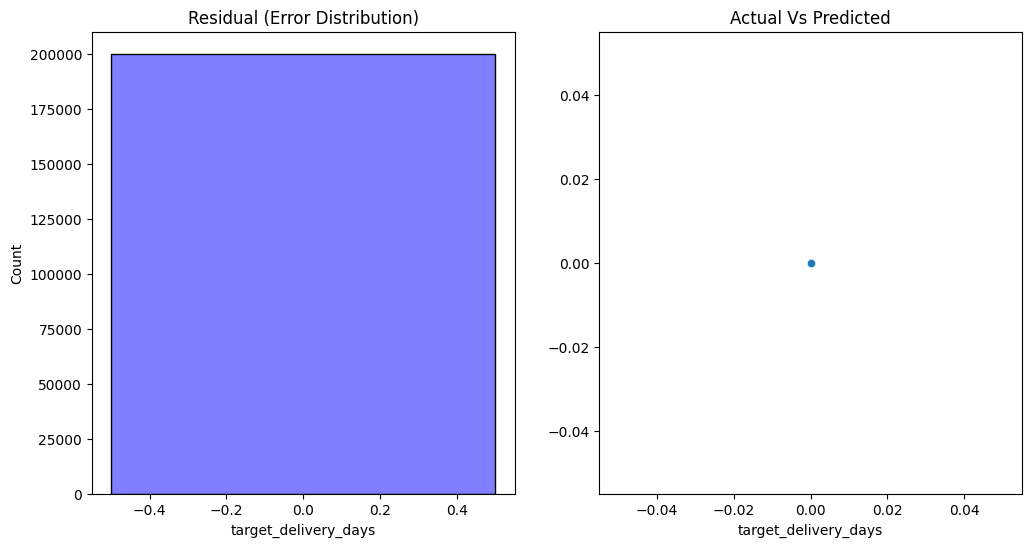

In [53]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

for col in num_cols:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].mean())

df_encoded = df_encoded.fillna(0)

X= df_encoded.drop(columns=[target, 'id'])
y= df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, preds):.4f}")
print(f"MAE : {mean_absolute_error(y_test, preds):.2f}")

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_
}).sort_values(by='Weight', ascending=False)

print("\n-----Top Drivers")
print(coef_df.head(10))

# Plot
plt.figure(figsize=(12,6))

#residual
plt.subplot(1,2,1)
sns.histplot(y_test - preds, kde=True, color='blue')
plt.title('Residual (Error Distribution)')\

#actual Predicted

plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title("Actual Vs Predicted")
plt.show()

In [57]:
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr = numeric_df.corr()[target].sort_values(ascending=False)
print(corr.head(20))


target_delivery_days    NaN
mrp                     NaN
listing_price           NaN
listing_quality_score   NaN
total_discounts         NaN
warehouse_proc_hours    NaN
Name: target_delivery_days, dtype: float64


In [58]:
import numpy as np
print(df_encoded[target].dtype)

int64


In [60]:
numeric_df = df_encoded.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(subset=[target])
corrs = numeric_df.corr()[target].sort_values(ascending=False)
print(corrs.head(10))

target_delivery_days    NaN
mrp                     NaN
listing_price           NaN
listing_quality_score   NaN
total_discounts         NaN
warehouse_proc_hours    NaN
Name: target_delivery_days, dtype: float64


In [61]:
print(df[target].unique())

[0]


In [62]:
print(df[target].describe())

count    1000000.0
mean           0.0
std            0.0
min            0.0
25%            0.0
50%            0.0
75%            0.0
max            0.0
Name: target_delivery_days, dtype: float64
